Matrica kamere:
 [[ 102.23646 -230.83709  -64.91724 1263.15041]
 [  65.25054   64.26781 -271.81081 1590.53588]
 [  -0.04656   -0.02802   -0.05675    1.     ]]

Centar kamere:
 [6.94443 6.03214 8.94496 1.     ]

Unutrasnja matrica kamere:
 [[3200.55974   11.71593  873.4312 ]
 [   0.      3222.49537 1714.96213]
 [   0.         0.         1.     ]]

Spoljasnja matrica kamere:
 [[-0.56615 -0.57304  0.59254]
 [ 0.82223 -0.4436   0.3566 ]
 [ 0.0585   0.68909  0.72231]]


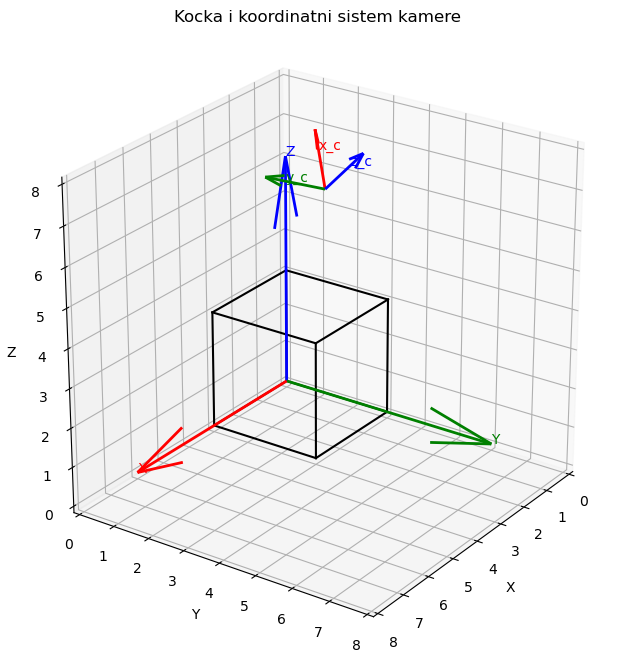

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def dve_jed(slika, org):
    nula=np.array([0, 0, 0, 0])
    prva=np.array(np.concatenate((nula, -slika[2]*org, slika[1]*org)))
    druga=np.array(np.concatenate((slika[2]*org, nula, -slika[0]*org)))
    return [prva, druga]

def napraviMatricu(slike1, orgs1):
    a=[]
    for i in range(len(slike1)):
        M=dve_jed(slike1[i], orgs1[i])
        a.append(M[0])
        a.append(M[1])
    return a
    

def matricaKamere(slike, orgs):
    A=napraviMatricu(slike, orgs)
    A=np.array(A)
    U, S, Vh = np.linalg.svd(A)
    t=Vh[11]
    t=t/t[11]
    t=np.where(np.isclose(t, 0), 0.0, t)
    t=t.reshape(3, 4)
    return t

def centar(T):
    C1=np.linalg.det(np.delete(T, 0, 1))
    C2=np.linalg.det(np.delete(T, 1, 1))
    C3=np.linalg.det(np.delete(T, 2, 1))
    C4=np.linalg.det(np.delete(T, 3, 1))
    c=-np.array([C1, -C2, C3, -C4])/C4
    c=np.where(np.isclose(c, 0), 0.0, c)
    return c

def unutrasnja(T):
    T0=np.delete(T, 3, 1)
    T0i=np.linalg.inv(T0)
    Q, R=np.linalg.qr(T0i)
    if(R[0,0]<0):
        R=np.matmul(np.diag([-1, 1, 1]), R)
        Q=np.matmul(Q, np.diag([-1, 1, 1]))
    if(R[1, 1]<0):
        R=np.matmul(np.diag([1, -1, 1]),R)
        Q=np.matmul(Q, np.diag([1, -1, 1]))
    if(R[2, 2]<0):
        R=np.matmul(np.diag([1, 1, -1]), R)
        Q=np.matmul(Q, np.diag([1, 1, -1]))
    k=np.linalg.inv(R)
    k=k/k[2, 2]
    k=np.where(np.isclose(k, 0), 0.0, k)
    return k

def spoljasnja(T):
    T0=np.delete(T, 3, 1)
    T0i=np.linalg.inv(T0)
    Q, R = np.linalg.qr(T0i)
    if(R[0, 0]<0):
        R=np.matmul(np.diag([-1, 1, 1]), R)
        Q=np.matmul(Q, np.diag([-1, 1, 1]))
    if(R[1, 1]<0):
        R=np.matmul(np.diag([1, -1, 1]), R)
        Q=np.matmul(Q, np.diag([1, -1, 1]))
    if(R[2, 2]<0):
        R=np.matmul(np.diag([1, 1, -1]), R)
        Q=np.matmul(Q, np.diag([1, 1, -1]))
    a=Q
    a=np.where(np.isclose(a, 0), 0.0, a)
    return a

def prikaz(A, C):
    c0=C[:3]

    tacke = np.array([
        [0,0,0], [3,0,0], [3,3,0], [0,3,0],
        [0,0,3], [3,0,3], [3,3,3], [0,3,3]
    ])

    ivice = [
        (0,1),(1,2),(2,3),(3,0),
        (4,5),(5,6),(6,7),(7,4),
        (0,4),(1,5),(2,6),(3,7)
    ]

    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(projection='3d')

    for i in ivice:
        v0 = tacke[i[0]]
        v1 = tacke[i[1]]
        ax.plot([v0[0], v1[0]], [v0[1], v1[1]], [v0[2], v1[2]], color='black')

    ax.quiver(0, 0, 0, 6, 0, 0, color='r', linewidth=2)
    ax.quiver(0, 0, 0, 0, 6, 0, color='g', linewidth=2)
    ax.quiver(0, 0, 0, 0, 0, 6, color='b', linewidth=2)
    ax.text(6, 0, 0, 'X', color='r')
    ax.text(0, 6, 0, 'Y', color='g')
    ax.text(0, 0, 6, 'Z', color='b')

    x_c = A[0]
    y_c = A[1]
    z_c = A[2]

    ax.quiver(*c0, *x_c, color='r', length=1.5, linewidth=2)
    ax.quiver(*c0, *y_c, color='g', length=1.5, linewidth=2)
    ax.quiver(*c0, *z_c, color='b', length=1.5, linewidth=2)

    ax.text(*(c0+x_c), 'x_c', color='r')
    ax.text(*(c0+y_c), 'y_c', color='g')
    ax.text(*(c0+z_c), 'z_c', color='b')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_box_aspect([1,1,1])
    ax.view_init(elev=25, azim=35)
    ax.set_title('Kocka i koordinatni sistem kamere')

    ax.set_xlim(0, 8)
    ax.set_ylim(0, 8)
    ax.set_zlim(0, 8)

    plt.show()

np.set_printoptions(precision=5, suppress=True)

P2D=np.array([1,-1,-1])*(np.array([3024,0,0])-np.array([[1750,925,1], [2530,1296,1], [1916,1879,1], [1050,1383,1], [1190,2082,1], [1910,2553,1], [2398,1936,1], [1769, 1594,1]]))
P3D=np.array([[0, 0, 3, 1], [0, 3, 3, 1], [3, 3, 3, 1], [3, 0, 3, 1], [3, 0, 0, 1], [3, 3, 0, 1], [0, 3, 0, 1], [2, 2, 3, 1]])

T=matricaKamere(P2D, P3D)
print("Matrica kamere:\n", T)

t0=np.delete(T, 3, 1)
if(np.linalg.det(t0)<0):
    T=-T

C=centar(T)
print("\nCentar kamere:\n", C)

K=unutrasnja(T)
print("\nUnutrasnja matrica kamere:\n", K)

A=spoljasnja(T)
print("\nSpoljasnja matrica kamere:\n", A)

prikaz(A, C)